# Limpeza dos dados

In [11]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

df = pd.read_csv("ships.csv", encoding="latin1")

df.shape

(5191, 16)

## Limpeza na base de dados

In [12]:
raw_cols = ["DWT", "LBP", "B", "D", "d", "Vs"]

n_before = len(df)
df = df[(df[raw_cols] != 0).all(axis=1)].reset_index(drop=True)
print(f"{n_before - len(df)} linhas removidas por conter zero em alguma coluna inicial ({len(df)} restantes)")

df.to_csv("ships.csv", index=False, encoding="latin1")
df.head()


0 linhas removidas por conter zero em alguma coluna inicial (5191 restantes)


,SHIP'S NAME,COUNTRY,DWT,LBP,B,D,d,Vs,L/B,L/D,B/D,B/d,L/d,D/d,T/D,Fr
0,CANOPUS,U.S.A.,31000,163.3,26.0,14.75,11.2,7.7160,6.280769,11.071186,1.762712,2.321429,14.580357,1.316964,0.759322,0.192781
1,FLYING OFFICER NIRMAL JIT SINGH SEKHON PVC,INDIA,40700,184.0,30.4,17.80,12.4,7.2016,6.052632,10.337079,1.707865,2.451613,14.838710,1.435484,0.696629,0.169506
2,LIEUTENANT ARUN KHETARPAL PVC,INDIA,40700,184.0,30.4,17.80,12.4,7.2016,6.052632,10.337079,1.707865,2.451613,14.838710,1.435484,0.696629,0.169506
3,MAJOR HOSHIAR SINGH PVC,INDIA,40700,184.0,30.4,17.80,12.4,7.2016,6.052632,10.337079,1.707865,2.451613,14.838710,1.435484,0.696629,0.169506
4,LANCE NAIK ALBERT EKKA PVC,INDIA,40700,184.0,30.4,17.80,12.4,7.2016,6.052632,10.337079,1.707865,2.451613,14.838710,1.435484,0.696629,0.169506


## Gráficos de dispersão

### Restrições

In [13]:
Suez = {
    "B": 77.5,
    "L": 400,
    "d": 18.89
}

Panama = {
    "B": 32.31,
    "L": 289.6,
    "d": 12.04
}

St_Lawrence = {
    "B": 23.8,
    "L": 222.5,
    "d": 7.92
}

Req_proj = {
    "Vs": 15.3*0.5144,
    "DWT": 45100,
}

label_dict = {
    "B": "Breadth [m]",
    "D": "Depth [m]",
    "LBP": "Length Between Perpendiculars [m]",
    "d": "Scantling Draft [m]",
    "DWT": "DWT [t]",
    "Vs": "Speed [m/s]",
}

SCATTER_PAIRS = [
    ("DWT", "LBP"),
    ("DWT", "B"),
    ("DWT", "D"),
    ("DWT", "d"),
    ("DWT", "Vs"),
    ("LBP", "B"),
    ("B", "D"),
    ("LBP", "D"),
    ("LBP", "L/B"),
    ("LBP", "B/D"),
    ("LBP", "L/D"),
    ("LBP", "T/D"),
]

# pares (x, y) em que a curva de regressao polinomial (DWT/LBP x dimensao) e mostrada
REGRESSION_PAIRS = {
    ("DWT", "LBP"), ("DWT", "B"), ("DWT", "D"), ("DWT", "d"), ("DWT", "Vs"),
    ("LBP", "B"), ("LBP", "D"),
}

# coluna -> chave usada nos dicionarios de restricao de porto (valor maximo permitido)
PORT_LIMIT_KEY_MAP = {"LBP": "L", "B": "B", "d": "d"}
PORT_LIMITS = {
    "Suez": Suez,
    "Panama": Panama,
    "St_Lawrence": St_Lawrence,
}

# coluna -> chave usada no requisito de projeto
REQ_KEY_MAP = {"DWT": "DWT", "Vs": "Vs"}


RESTRICTION_COLORS = {
    "Suez": "tab:orange",
    "Panama": "tab:green",
    "St_Lawrence": "tab:purple",
    "Req_proj": "tab:red",
}


### Regressões TUD 2008

In [14]:
def reg_LBP(DWT):
    return 41.647 * DWT**(0.133)

def reg_B(DWT):
    return min(15.04 + 0.000369 * DWT, 32.2)

def reg_D(DWT):
    return 9.69 + 0.000188 * DWT

def reg_d(DWT):
    return 7.41 + 0.000106 * DWT

### Plots

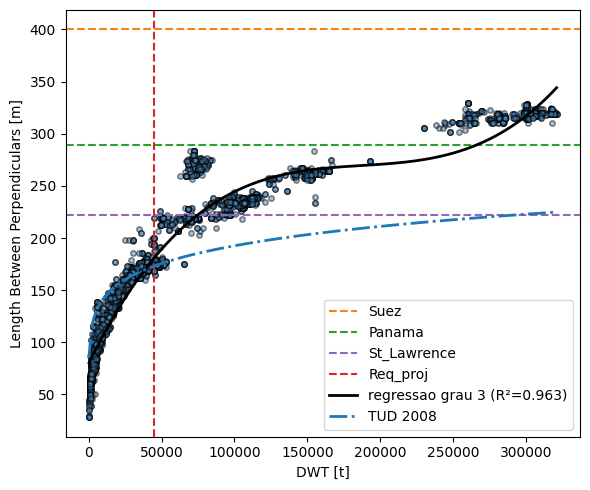

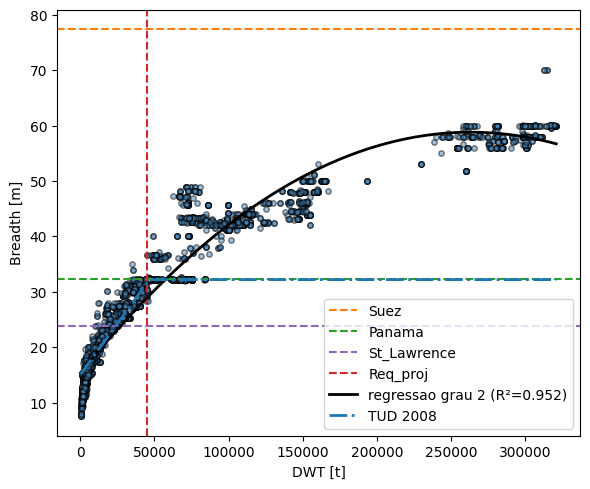

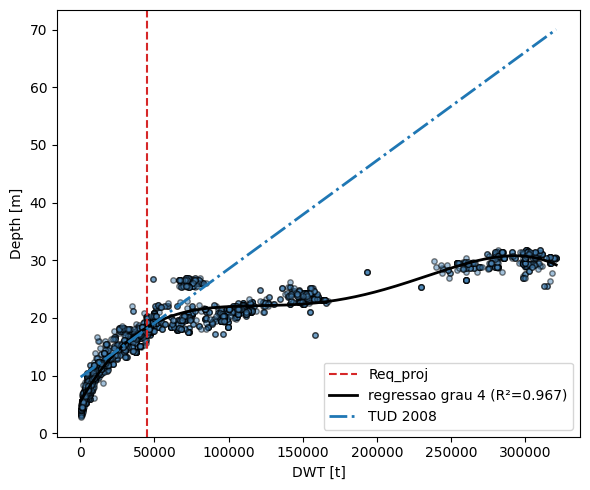

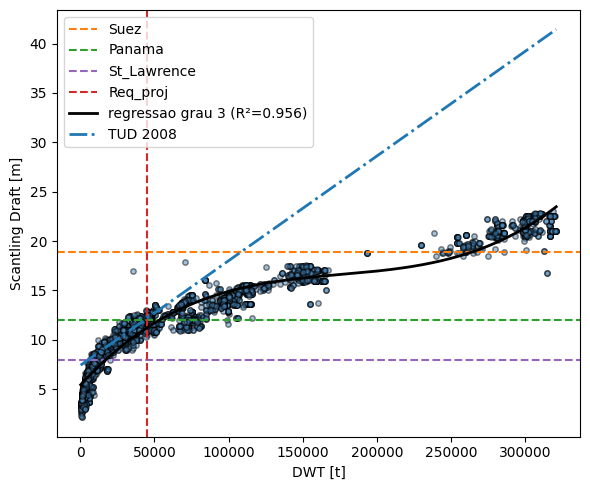

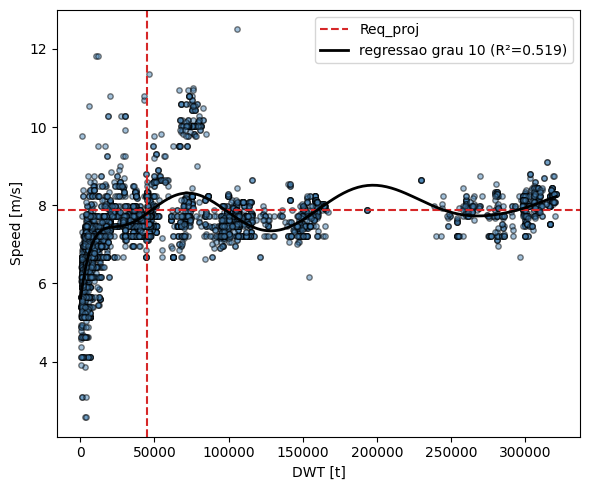

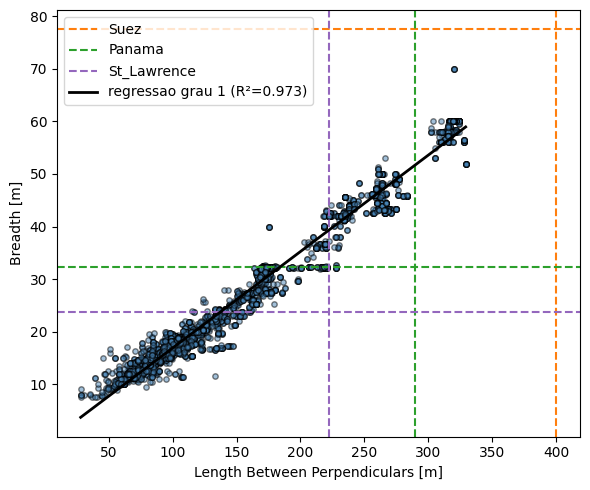

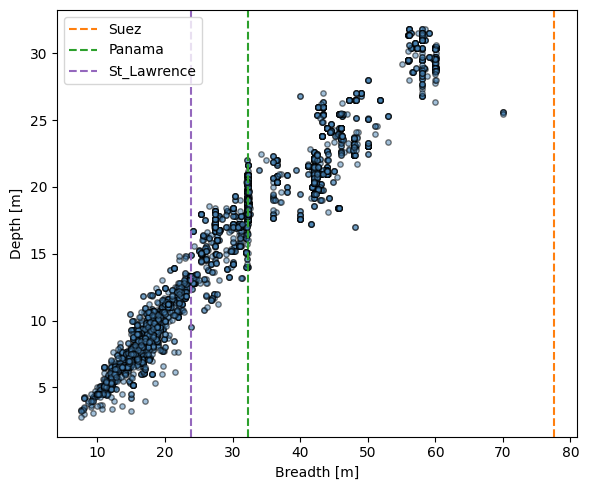

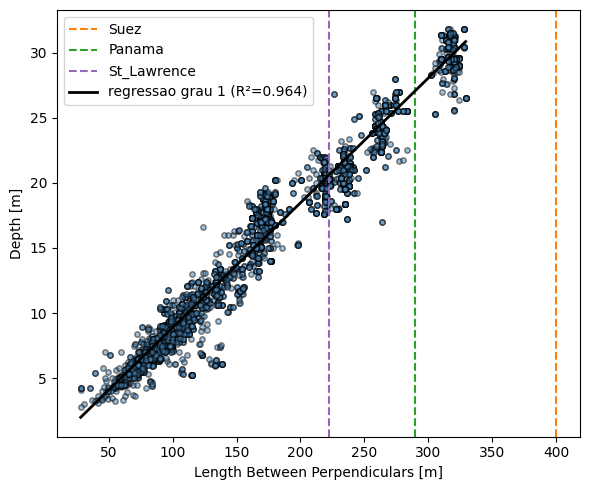

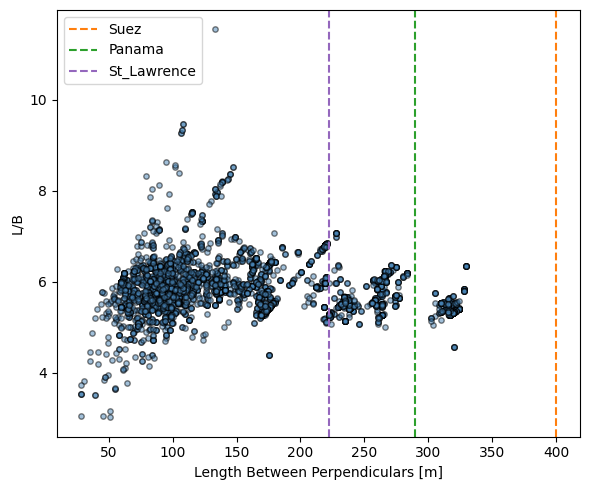

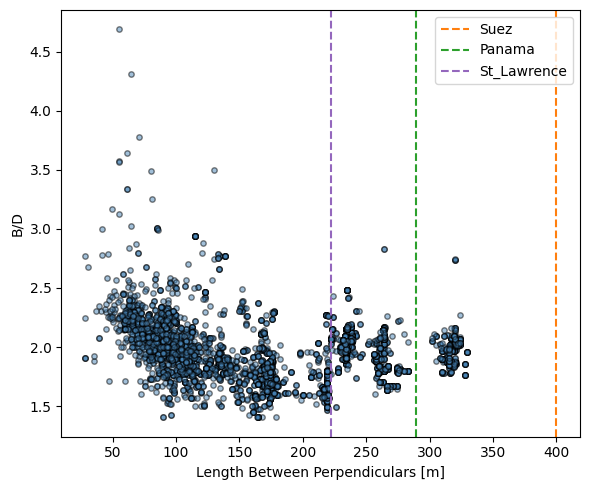

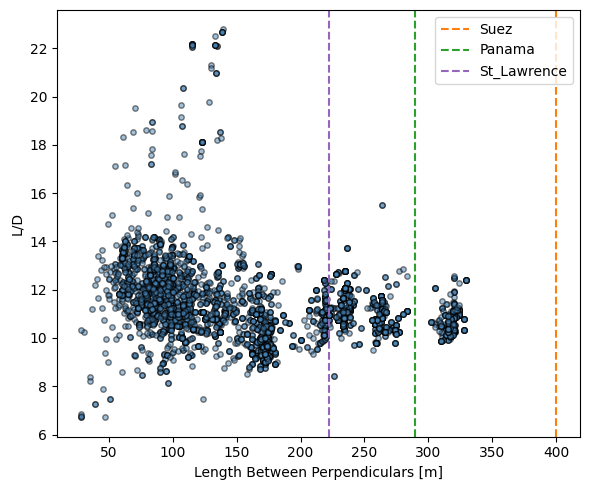

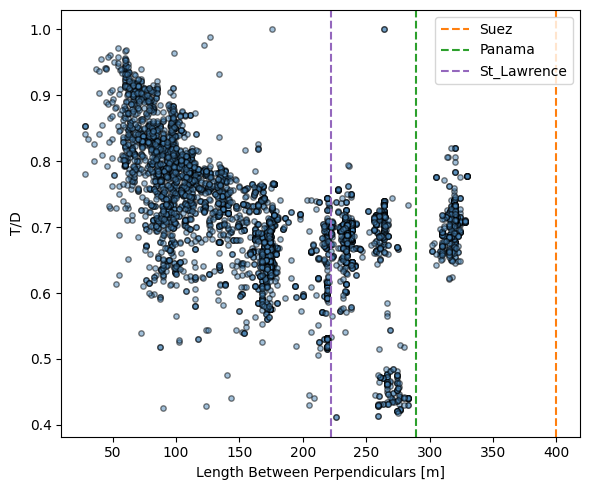

In [15]:
from numpy.polynomial import Polynomial

MARGIN = 0.1  # 10% de folga para os pontos nao ficarem colados nas bordas


def poly_r2(x, y, degree):
    p = Polynomial.fit(x, y, degree)
    y_pred = p(x)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return p, 1 - ss_res / ss_tot


def best_polynomial(x, y, max_degree=10, r2_threshold=0.95):
    """menor grau (<= max_degree) que atinge r2_threshold; senao, o de maior R^2."""
    best_p, best_r2, best_degree = None, -np.inf, None
    for degree in range(1, max_degree + 1):
        p, r2 = poly_r2(x, y, degree)
        if best_p is None or r2 > best_r2:
            best_p, best_r2, best_degree = p, r2, degree
        if r2 >= r2_threshold:
            return p, r2, degree
    return best_p, best_r2, best_degree


# regressoes empiricas TUD 2008 (parametro em funcao do DWT)
TUD_REGRESSIONS = {
    "LBP": reg_LBP,
    "B": reg_B,
    "D": reg_D,
    "d": reg_d,
}


for x, y in SCATTER_PAIRS:
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(df[x], df[y], color="steelblue", edgecolor="black", alpha=0.5, s=15)
    ax.set_xlabel(label_dict.get(x, x))
    ax.set_ylabel(label_dict.get(y, y))
    # ax.set_title(f"{x} x {y}")

    x_min, x_max = df[x].min(), df[x].max()
    y_min, y_max = df[y].min(), df[y].max()

    # restricoes de porto: linha tracejada no valor maximo permitido
    for name, limits in PORT_LIMITS.items():
        color = RESTRICTION_COLORS[name]
        x_key = PORT_LIMIT_KEY_MAP.get(x)
        y_key = PORT_LIMIT_KEY_MAP.get(y)
        if x_key in limits:
            ax.axvline(limits[x_key], color=color, linestyle="--", label=name)
            x_max = max(x_max, limits[x_key])
        if y_key in limits:
            ax.axhline(limits[y_key], color=color, linestyle="--", label=name)
            y_max = max(y_max, limits[y_key])

    # requisito de projeto: linha tracejada no valor alvo
    x_req_key = REQ_KEY_MAP.get(x)
    y_req_key = REQ_KEY_MAP.get(y)
    if x_req_key in Req_proj:
        ax.axvline(Req_proj[x_req_key], color=RESTRICTION_COLORS["Req_proj"], linestyle="--", label="Req_proj")
        x_max = max(x_max, Req_proj[x_req_key])
    if y_req_key in Req_proj:
        ax.axhline(Req_proj[y_req_key], color=RESTRICTION_COLORS["Req_proj"], linestyle="--", label="Req_proj")
        y_max = max(y_max, Req_proj[y_req_key])

    # regressao polinomial (grau <= 10, buscando R^2 >= 0.95)
    if (x, y) in REGRESSION_PAIRS:
        x_data = df[x].to_numpy(dtype=float)
        y_data = df[y].to_numpy(dtype=float)
        p, r2, degree = best_polynomial(x_data, y_data)
        x_line = np.linspace(x_data.min(), x_data.max(), 200)
        ax.plot(
            x_line, p(x_line), color="black", linewidth=2,
            label=f"regressao grau {degree} (R²={r2:.3f})",
        )

    # regressao empirica TUD 2008 (parametro em funcao do DWT)
    if x == "DWT" and y in TUD_REGRESSIONS:
        dwt_line = np.linspace(df[x].min(), df[x].max(), 200)
        tud_values = np.array([TUD_REGRESSIONS[y](v) for v in dwt_line])
        ax.plot(dwt_line, tud_values, color="tab:blue", linewidth=2, linestyle="-.", label="TUD 2008")
        y_max = max(y_max, tud_values.max())

    x_pad = (x_max - x_min) * MARGIN or 1
    y_pad = (y_max - y_min) * MARGIN or 1

    handles, labels = ax.get_legend_handles_labels()
    if labels:
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys())

    plt.tight_layout()
    plt.show()


### Análise estatística

In [16]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()


def mode_of(series):
    m = series.mode()
    return m.iloc[0] if not m.empty else np.nan


stats_rows = {}
for col in numeric_cols:
    s = df[col].dropna()
    mean = s.mean()
    std = s.std(ddof=1)
    stats_rows[col] = {
        "media": mean,
        "mediana": s.median(),
        "max": s.max(),
        "min": s.min(),
        "moda": mode_of(s),
        "faixa": s.max() - s.min(),
        "erro padrao": stats.sem(s),
        "variancia": s.var(ddof=1),
        "desv pad": std,
        "coef variancia": std / mean if mean != 0 else np.nan,
        "skewness": stats.skew(s),
        "kurtosis": stats.kurtosis(s),
    }

stats_df = pd.DataFrame(stats_rows).T
stats_df


,media,mediana,max,min,moda,faixa,erro padrao,variancia,desv pad,coef variancia,skewness,kurtosis
DWT,71710.872279,39768.000000,321000.000000,232.000000,105000.000000,320768.000000,1225.376156,7.794529e+09,88286.630033,1.231147,1.594713,1.584247
LBP,176.312060,172.000000,329.180000,28.100000,234.000000,301.080000,1.096506,6.241273e+03,79.001726,0.448079,0.271417,-1.064533
B,30.908550,31.000000,70.000000,7.500000,42.000000,62.500000,0.203881,2.157765e+02,14.689331,0.475251,0.416443,-0.928183
D,16.201006,17.200001,31.799999,2.750000,21.000000,29.049999,0.107154,5.960270e+01,7.720278,0.476531,0.205293,-0.997463
d,11.207949,11.116000,23.070000,2.150000,16.000000,20.920000,0.069862,2.533607e+01,5.033495,0.449100,0.490224,-0.499787
Vs,7.352342,7.458800,12.499920,2.572000,7.716000,9.927920,0.012985,8.753022e-01,0.935576,0.127249,0.034595,2.743882
L/B,5.785066,5.608696,11.547826,3.025595,5.571429,8.522231,0.007642,3.031498e-01,0.550590,0.095174,1.287036,7.142693
L/D,11.220024,11.032864,22.786886,6.711840,11.142857,16.075046,0.021535,2.407288e+00,1.551544,0.138283,2.735921,15.293337
B/D,1.945899,1.943529,4.687500,1.405556,2.000000,3.281944,0.003344,5.804897e-02,0.240934,0.123816,1.523197,9.016424
B/d,2.747322,2.666667,6.818182,1.611765,3.000000,5.206417,0.005690,1.680354e-01,0.409921,0.149208,1.830426,6.547047


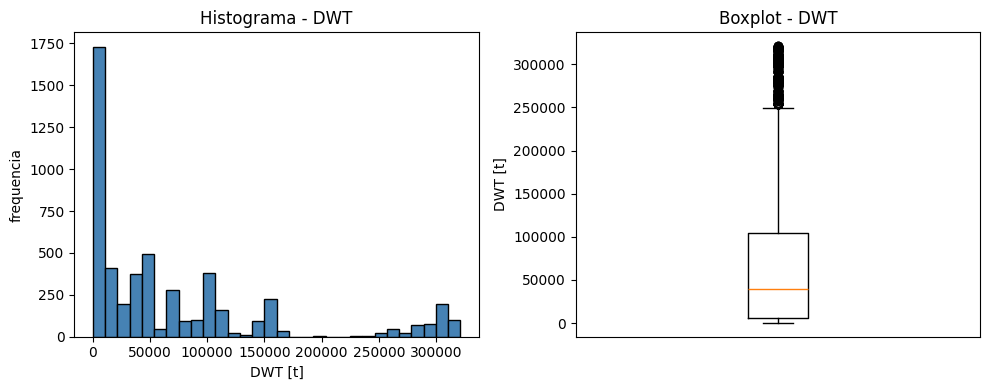

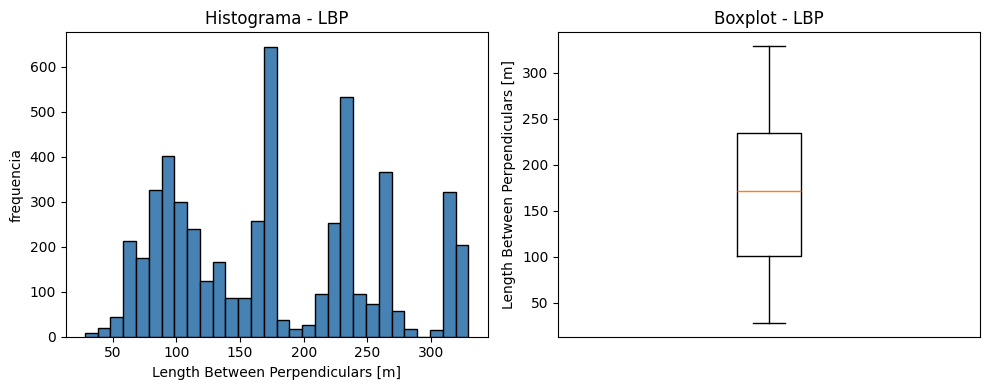

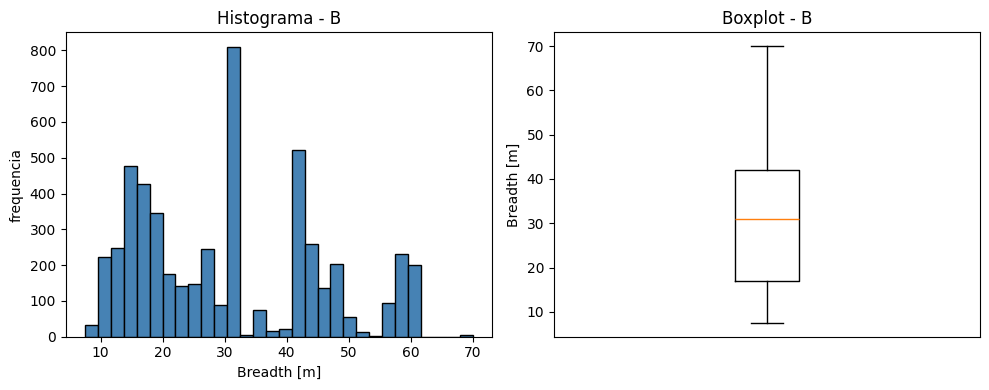

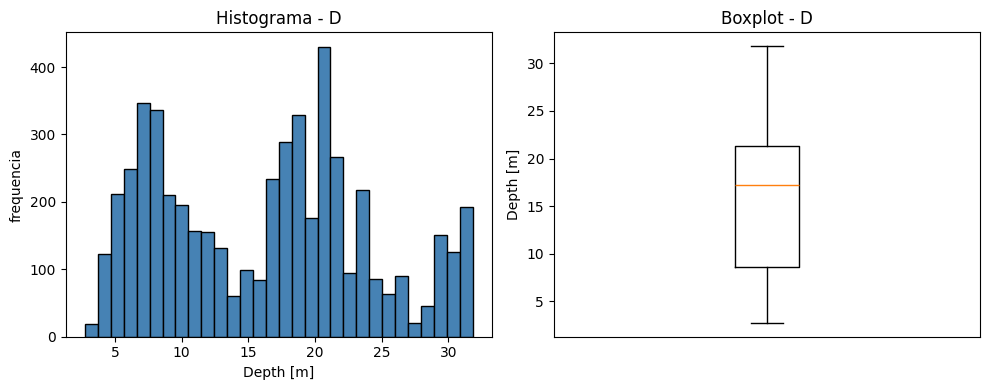

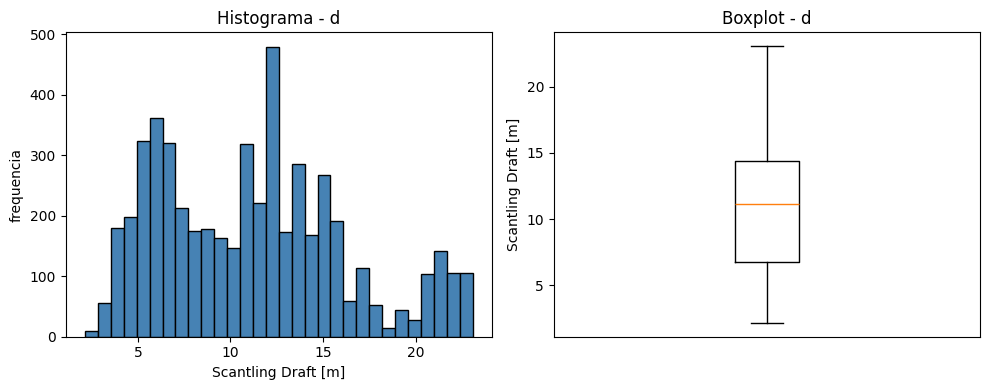

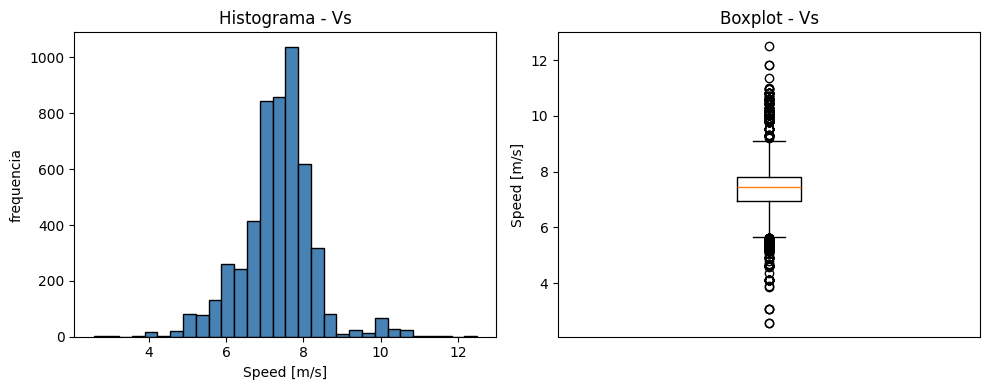

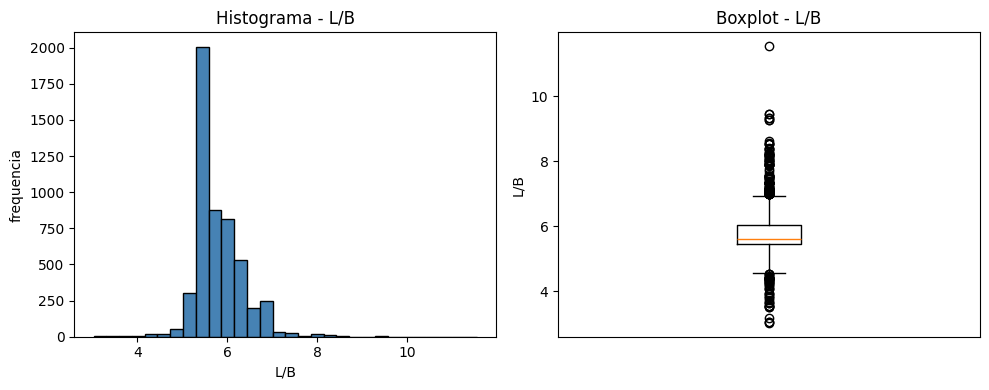

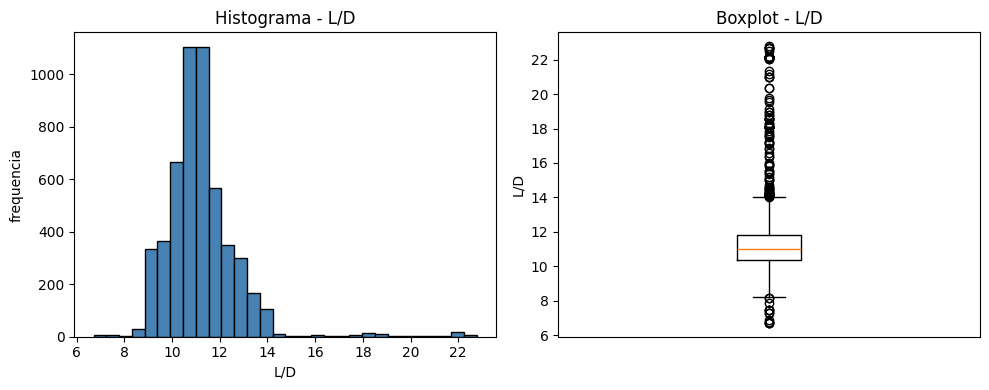

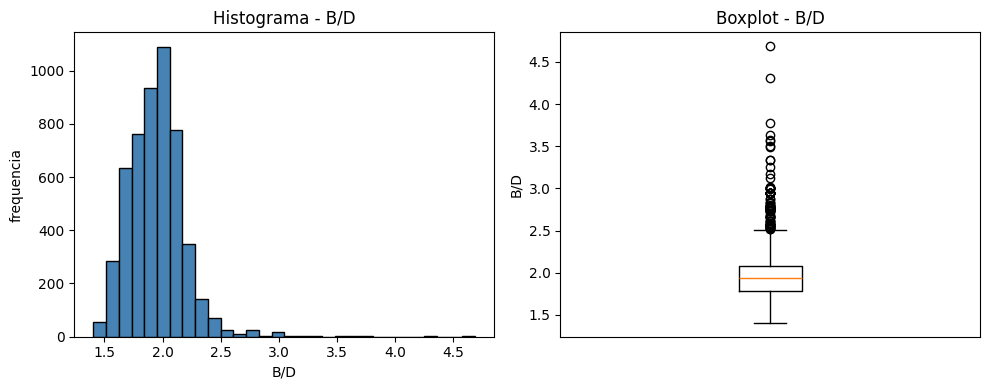

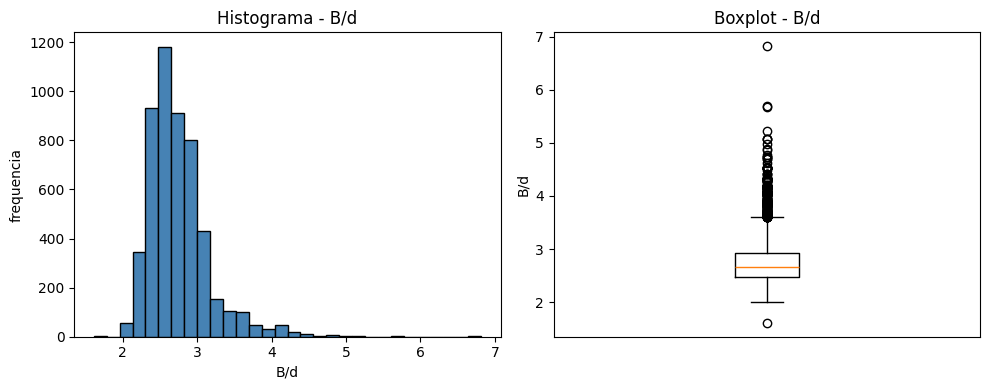

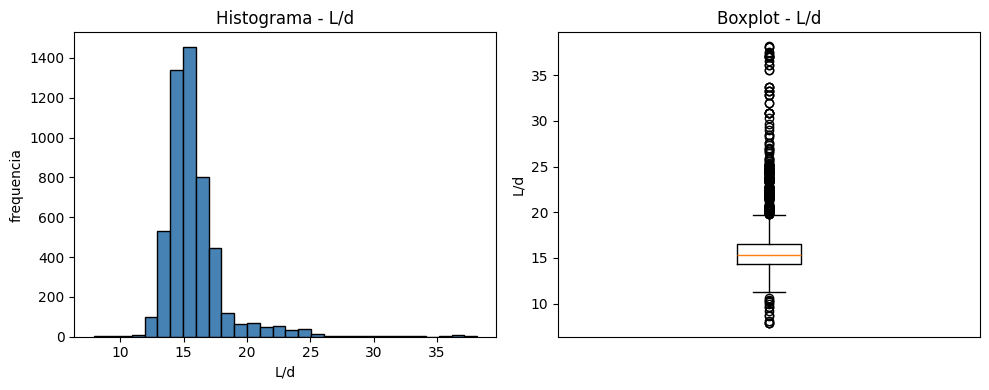

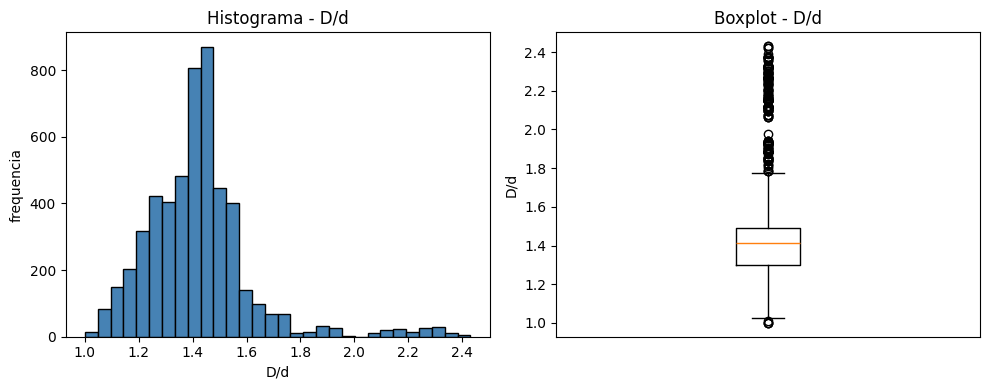

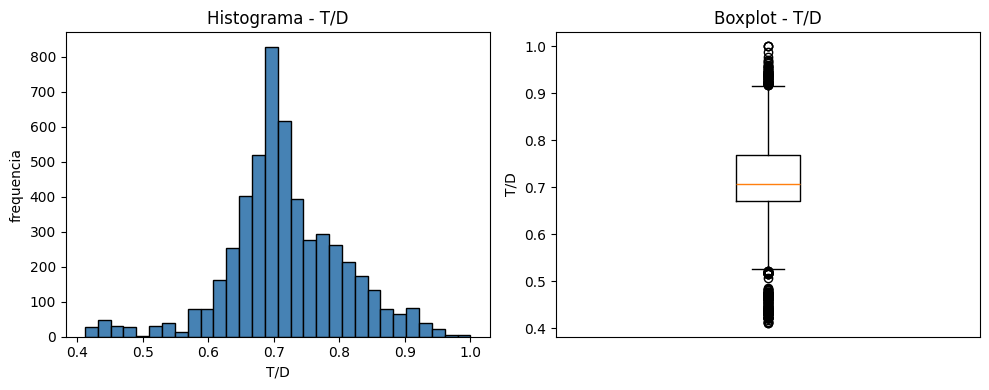

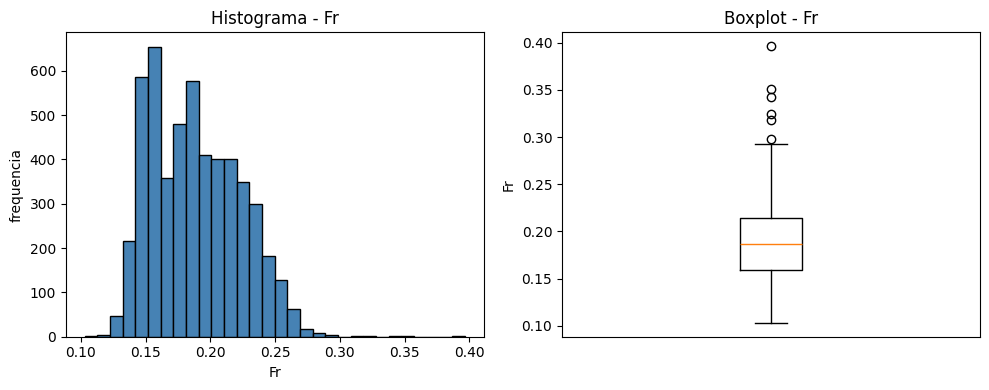

In [17]:
for col in numeric_cols:
    s = df[col].dropna()
    fig, (ax_hist, ax_box) = plt.subplots(1, 2, figsize=(10, 4))
 
    ax_hist.hist(s, bins=30, color="steelblue", edgecolor="black")
    ax_hist.set_xlabel(label_dict.get(col, col))
    ax_hist.set_ylabel("frequencia")
    ax_hist.set_title(f"Histograma - {col}")

    ax_box.boxplot(s, vert=True)
    ax_box.set_ylabel(label_dict.get(col, col))
    ax_box.set_title(f"Boxplot - {col}")
    ax_box.set_xticks([])

    plt.tight_layout()
    plt.show()


## Estimativas iniciais